# Item-Item Collaborative Filtering on MovieLens 100K

This notebook implements a fast item-item CF using sparse matrices and sklearn NearestNeighbors, evaluates RMSE/MAE and Precision/Recall@K, and plots results.

In [3]:
# 1. Imports & configuration
import os, zipfile, urllib.request
from pathlib import Path
import numpy as np
import pandas as pd
from math import sqrt
from sklearn.neighbors import NearestNeighbors
from sklearn.metrics import mean_squared_error, mean_absolute_error
from scipy import sparse
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')
# %matplotlib inline

DATA_URL = 'https://files.grouplens.org/datasets/movielens/ml-100k.zip'
DATA_DIR = Path('./ml-100k')
RATING_FILE = DATA_DIR / 'u.data'
TEST_FRAC = 0.2
K_NEIGHBORS = 20
NN_PRECOMPUTE = K_NEIGHBORS + 1
TOPN = 10
SEED = 42
np.random.seed(SEED)

print('Config: K=', K_NEIGHBORS, 'TOPN=', TOPN)

Config: K= 20 TOPN= 10


In [4]:
# 2. Download and load MovieLens 100K
if not DATA_DIR.exists() or not RATING_FILE.exists():
    print('Downloading MovieLens 100K...')
    zip_path = Path('ml-100k.zip')
    urllib.request.urlretrieve(DATA_URL, zip_path)
    with zipfile.ZipFile(zip_path, 'r') as z:
        z.extractall('.')
    zip_path.unlink()
    print('Downloaded and extracted.')
else:
    print('Dataset found at', DATA_DIR)

cols = ['user_id','item_id','rating','timestamp']
ratings = pd.read_csv(RATING_FILE, sep='\t', names=cols, engine='python')
ratings = ratings.drop(columns=['timestamp'])
ratings['user'] = 'u' + ratings['user_id'].astype(str)
ratings['item'] = 'i' + ratings['item_id'].astype(str)
ratings = ratings[['user','item','rating']]
print(f"Loaded {len(ratings)} ratings: {ratings['user'].nunique()} users, {ratings['item'].nunique()} items")

Dataset found at ml-100k
Loaded 100000 ratings: 943 users, 1682 items


In [5]:
# 3. Train-test split (per-user)
def train_test_split_per_user(df, test_frac=0.2, seed=42):
    np.random.seed(seed)
    train_rows = []
    test_rows = []
    for u, g in df.groupby('user'):
        g_shuf = g.sample(frac=1.0, random_state=seed)
        n = len(g_shuf)
        if n == 0:
            continue
        test_n = max(1, int(np.floor(n * test_frac)))
        test_rows.append(g_shuf.iloc[:test_n])
        if n - test_n > 0:
            train_rows.append(g_shuf.iloc[test_n:])
    train_df = pd.concat(train_rows).reset_index(drop=True) if train_rows else pd.DataFrame(columns=df.columns)
    test_df = pd.concat(test_rows).reset_index(drop=True) if test_rows else pd.DataFrame(columns=df.columns)
    return train_df, test_df

train_df, test_df = train_test_split_per_user(ratings, test_frac=TEST_FRAC, seed=SEED)
print('Train ratings:', len(train_df), 'Test ratings:', len(test_df))

Train ratings: 80367 Test ratings: 19633


In [6]:
# 4. Build index maps and sparse CSR user-item matrix
all_users = sorted(ratings['user'].unique())
all_items = sorted(ratings['item'].unique())
user_to_idx = {u:i for i,u in enumerate(all_users)}
item_to_idx = {it:i for i,it in enumerate(all_items)}
idx_to_user = {i:u for u,i in user_to_idx.items()}
idx_to_item = {i:it for it,i in item_to_idx.items()}

rows = train_df['user'].map(user_to_idx).astype(int).values
cols = train_df['item'].map(item_to_idx).astype(int).values
data = train_df['rating'].astype(float).values
n_users = len(all_users)
n_items = len(all_items)
R_csr = sparse.csr_matrix((data, (rows, cols)), shape=(n_users, n_items))
print('CSR matrix built:', R_csr.shape, ' nnz=', R_csr.nnz)

# Precompute user means and global mean for fallbacks
user_means = train_df.groupby('user')['rating'].mean().to_dict()
global_mean = train_df['rating'].mean()
print('Global mean rating (train):', global_mean)

CSR matrix built: (943, 1682)  nnz= 80367
Global mean rating (train): 3.5313499321860964


In [7]:
# 5. Compute item-item similarities using NearestNeighbors (cosine)
print('Fitting NearestNeighbors on item vectors...')
R_items = R_csr.T  # items x users
nn_item = NearestNeighbors(n_neighbors=NN_PRECOMPUTE, metric='cosine', n_jobs=-1)
nn_item.fit(R_items)
dist_i, idx_i = nn_item.kneighbors(R_items, return_distance=True)
sim_i = 1.0 - dist_i

# Clean neighbor lists: remove self and keep top-K
item_neighbors = [None] * n_items
item_sims = [None] * n_items
for i_idx in range(n_items):
    neigh = idx_i[i_idx]
    sims = sim_i[i_idx]
    mask = neigh != i_idx
    neigh2 = neigh[mask][:K_NEIGHBORS]
    sims2 = sims[mask][:K_NEIGHBORS]
    item_neighbors[i_idx] = neigh2
    item_sims[i_idx] = sims2
print('Item-item neighbors computed for', n_items, 'items')

Fitting NearestNeighbors on item vectors...
Item-item neighbors computed for 1682 items


In [8]:
# 6. Precompute user -> (item_idx, rating) mapping
user_to_items = {}
for u, g in train_df.groupby('user'):
    item_idx_arr = g['item'].map(item_to_idx).astype(int).values
    ratings_arr = g['rating'].astype(float).values
    user_to_items[u] = (item_idx_arr, ratings_arr)
print('Built user->items for', len(user_to_items), 'users')

Built user->items for 943 users


In [9]:
# 7. Predict function (item-item), analogous to user-user predictor
import numpy as np

def predict_item_item(user, item, k=K_NEIGHBORS, shrinkage=0.0):
    """Predict rating for (user, item) using item-item CF: weighted average of user's ratings on similar items"""
    if user not in user_to_items or item not in item_to_idx:
        return np.nan
    i_idx = item_to_idx[item]
    neigh_idxs = item_neighbors[i_idx]
    neigh_sims = item_sims[i_idx]
    # user's rated items
    rated_idx, rated_vals = user_to_items[user]
    if rated_idx.size == 0:
        return np.nan
    rated_set = set(rated_idx.tolist())
    mask = np.array([int(n) in rated_set for n in neigh_idxs])
    if not mask.any():
        return np.nan
    chosen_items = neigh_idxs[mask]
    chosen_sims = neigh_sims[mask]
    rmap = {int(it): float(r) for it, r in zip(rated_idx, rated_vals)}
    neigh_ratings = np.array([rmap[int(it)] for it in chosen_items])
    denom = np.abs(chosen_sims).sum() + shrinkage
    if denom == 0:
        return np.nan
    pred = (chosen_sims * neigh_ratings).sum() / denom
    return pred

# quick sanity checks
for _, row in test_df.head(5).iterrows():
    u, it, r = row['user'], row['item'], row['rating']
    print('user', u, 'item', it, 'true', r, 'pred', predict_item_item(u, it))

user u1 item i31 true 3 pred 4.200947019986595
user u1 item i39 true 4 pred 4.070163121944019
user u1 item i163 true 4 pred 4.450715667168242
user u1 item i226 true 3 pred 3.6460405739948825
user u1 item i169 true 5 pred 4.400948565805868


In [10]:
# 8. Evaluate rating prediction (RMSE / MAE)
y_true = []
y_pred = []
for _, row in test_df.iterrows():
    u, it, r = row['user'], row['item'], row['rating']
    p = predict_item_item(u, it)
    if np.isnan(p):
        p = user_means.get(u, global_mean)
    y_true.append(r)
    y_pred.append(p)

rmse = sqrt(mean_squared_error(y_true, y_pred))
mae = mean_absolute_error(y_true, y_pred)
print('Item-Item RMSE:', rmse, 'MAE:', mae)

Item-Item RMSE: 0.9879396716330665 MAE: 0.7599870584145011


In [11]:
# 9. Top-N evaluation: Precision@K, Recall@K

def recommend_top_k_item(user, top_n=TOPN):
    if user not in user_to_items:
        return []
    seen_items = set(train_df[train_df['user'] == user]['item'])
    candidates = [it for it in all_items if it not in seen_items]
    scores = []
    for it in candidates:
        s = predict_item_item(user, it)
        scores.append((it, s if not np.isnan(s) else -999))
    scores.sort(key=lambda x: x[1], reverse=True)
    return [it for it, _ in scores[:top_n]]

precisions = []
recalls = []
for u in sorted(set(train_df['user']).intersection(set(test_df['user']))):
    true_items = set(test_df[test_df['user'] == u]['item'])
    if len(true_items) == 0:
        continue
    recs = recommend_top_k_item(u, top_n=TOPN)
    hit = len(set(recs) & true_items)
    precisions.append(hit / TOPN)
    recalls.append(hit / len(true_items))

print('Precision@{}:'.format(TOPN), np.mean(precisions), 'Recall@{}:'.format(TOPN), np.mean(recalls))

Precision@10: 0.011558854718981973 Recall@10: 0.008225605562151737


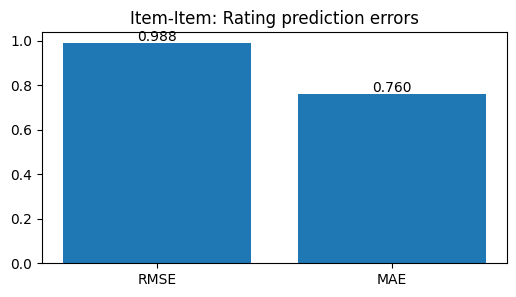

In [12]:
# 10. Plots
# Bar plot for RMSE/MAE (single values)
plt.figure(figsize=(6,3))
plt.bar(['RMSE','MAE'], [rmse, mae])
plt.title('Item-Item: Rating prediction errors')
for i,v in enumerate([rmse, mae]): plt.text(i, v+0.01, f"{v:.3f}", ha='center')
plt.show()

# Example: Precision & Recall values printed above
